In [12]:
import pandas as pd

In [13]:
ZONE_ID = "02"

In [14]:
# Import morning measurements
df = pd.read_csv("data/E17_zone" + ZONE_ID + "_morning.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
df["day"] = df["time"].dt.date

days = sorted(df["day"].unique())
day_index = {d: i for i, d in enumerate(days)}
day_labels = [str(d)[5:] for d in days]  # MM-DD

print(f"Date range: {days[0]} → {days[-1]}")
print(f"Total rows: {len(df)}, unique plant_ids: {df['plant_id'].nunique()}")

Date range: 2026-04-01 → 2026-04-15
Total rows: 740, unique plant_ids: 50


In [15]:
# Identify plants with missing dates, and remove them from df
all_ids = set(range(64))

missing_per_day = (
    df.groupby("day")["plant_id"]
    .apply(lambda ids: sorted(all_ids - set(ids)))
    .reset_index()
)
missing_per_day.columns = ["day", "missing_plant_ids"]
missing_per_day["n_missing"] = missing_per_day["missing_plant_ids"].apply(len)

# print(missing_per_day[["day", "n_missing", "missing_plant_ids"]].to_string(index=False))

all_days = set(df["day"].unique())

present_every_day = sorted(
    pid for pid, grp in df.groupby("plant_id")["day"] if set(grp) == all_days
)

print(f"plant_ids present every day ({len(present_every_day)}): {present_every_day}")

df = df[df["plant_id"].isin(present_every_day)].reset_index(drop=True)
print(f"Filtered rows: {len(df)}, unique plant_ids: {df['plant_id'].nunique()}")

plant_ids present every day (44): [3, 4, 5, 6, 7, 9, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 26, 27, 30, 31, 32, 33, 34, 35, 36, 37, 40, 42, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 58, 59, 60, 61, 62]
Filtered rows: 660, unique plant_ids: 44


In [16]:
# Identify plants with consecutive repeats
# (i.e. some of their areas were cleaned during CV outlier detection and their growth curves are typically messy)
# Exception: if ALL plants show a repeat on the same day transition, that transition is exempt (system-wide event)
# and the duplicate day (day n+1) is dropped from df entirely.

days_sorted = sorted(df["day"].unique())
plant_day_area = {
    pid: dict(zip(grp["day"], grp["clean_area"])) for pid, grp in df.groupby("plant_id")
}

exempt_transitions = set()
for d1, d2 in zip(days_sorted[:-1], days_sorted[1:]):
    if all(
        plant_day_area[pid][d1] == plant_day_area[pid][d2] for pid in plant_day_area
    ):
        exempt_transitions.add((d1, d2))

if exempt_transitions:
    days_to_remove = {d2 for _, d2 in exempt_transitions}
    print(f"Exempt day transitions (all plants repeated): {sorted(exempt_transitions)}")
    print(f"Removing duplicate days: {sorted(days_to_remove)}")
    df = df[~df["day"].isin(days_to_remove)].reset_index(drop=True)
    plant_day_area = {
        pid: dict(zip(grp["day"], grp["clean_area"]))
        for pid, grp in df.groupby("plant_id")
    }

no_consecutive_repeats = []
has_consecutive_repeats = []

for pid, grp in df.groupby("plant_id"):
    area_by_day = plant_day_area[pid]
    days_for_plant = sorted(area_by_day)
    has_repeat = any(
        area_by_day[d1] == area_by_day[d2]
        for d1, d2 in zip(days_for_plant[:-1], days_for_plant[1:])
        if (d1, d2) not in exempt_transitions
    )
    (has_consecutive_repeats if has_repeat else no_consecutive_repeats).append(pid)

print(
    f"Plants with NO consecutive identical clean_area values ({len(no_consecutive_repeats)}): {no_consecutive_repeats}"
)
print(
    f"Plants WITH consecutive identical clean_area values  ({len(has_consecutive_repeats)}): {has_consecutive_repeats}"
)

df = df[df["plant_id"].isin(no_consecutive_repeats)].reset_index(drop=True)
print(
    f"\nAfter removal — rows: {len(df)}, unique plant_ids: {df['plant_id'].nunique()}"
)

Plants with NO consecutive identical clean_area values (35): [3, 4, 5, 6, 7, 9, 13, 14, 15, 19, 20, 21, 22, 23, 26, 27, 30, 31, 32, 33, 34, 35, 36, 40, 42, 45, 47, 51, 52, 53, 54, 55, 58, 59, 60]
Plants WITH consecutive identical clean_area values  (9): [11, 12, 18, 37, 44, 46, 50, 61, 62]

After removal — rows: 525, unique plant_ids: 35


In [17]:
last_area = df.sort_values("day").groupby("plant_id")["clean_area"].last()
small_plants = last_area[last_area < 100].index.tolist()
print(
    f"Plants with last clean_area < 100 ({len(small_plants)}): {sorted(small_plants)}"
)

df = df[~df["plant_id"].isin(small_plants)].reset_index(drop=True)
print(f"After removal — rows: {len(df)}, unique plant_ids: {df['plant_id'].nunique()}")

Plants with last clean_area < 100 (1): [6]
After removal — rows: 510, unique plant_ids: 34


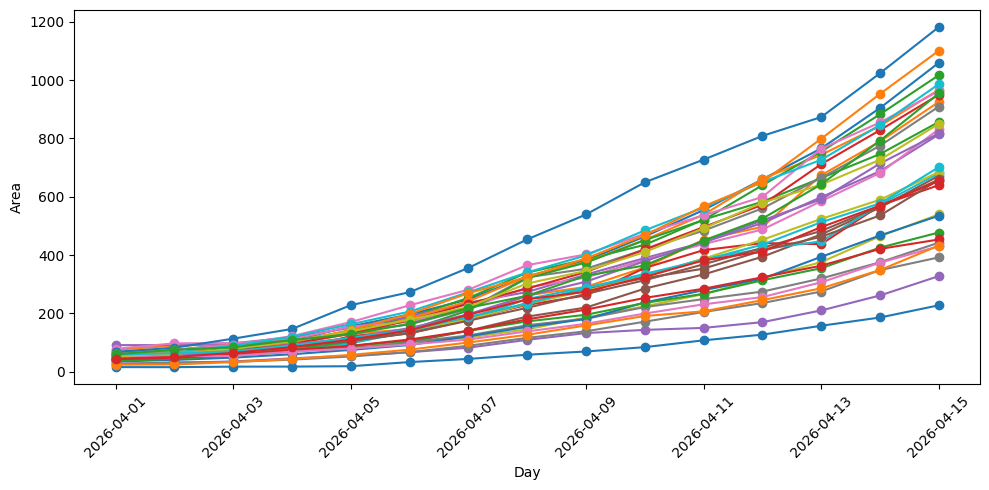

In [18]:
import matplotlib.pyplot as plt

# subset_ids = no_consecutive_repeats[:]
# subset = df[df["plant_id"].isin(subset_ids)]
subset = df
fig, ax = plt.subplots(figsize=(10, 5))
for pid, grp in subset.groupby("plant_id"):
    grp_sorted = grp.sort_values("day")
    ax.plot(
        grp_sorted["day"], grp_sorted["clean_area"], marker="o", label=f"plant {pid}"
    )

ax.set_xlabel("Day")
ax.set_ylabel("Area")
# ax.legend(title="plant_id")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
output_path = f"data/E17_zone{ZONE_ID}_morning.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} rows to {output_path}")

Saved 510 rows to data/E17_zone02_morning.csv
